In [1]:
import tensorflow
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Create a CNN network
cnn = Sequential()

In [3]:
# Convolution
cnn.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(64, 64, 3), activation="relu"))
# Pooling
cnn.add(MaxPooling2D(pool_size=(2, 2)))
# Convolution
cnn.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
# Pooling
cnn.add(MaxPooling2D(pool_size=(2, 2)))
# Flatten
cnn.add(Flatten())

C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Fully Connected Layers
cnn.add(Dense(64, activation="relu"))
cnn.add(Dense(32, activation="relu"))
cnn.add(Dense(16, activation="relu"))
cnn.add(Dense(8, activation="relu"))
cnn.add(Dense(4, activation="relu"))
cnn.add(Dense(2, activation="relu"))
cnn.add(Dense(1, activation="sigmoid"))

In [5]:
# Compile model
cnn.compile(optimizer="adam", loss="binary_crossentropy")

In [6]:
# Create an instance of ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True
)
# Same for test_datagen
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [7]:
# Generate batches of augmented image data from the specified directory
train_generator = train_datagen.flow_from_directory(
    "../assets/pictures/train", target_size=(64, 64), batch_size=32, class_mode="binary"
)
# Same for test_generator
test_generator = test_datagen.flow_from_directory(
    "../assets/pictures/test", target_size=(64, 64), batch_size=32, class_mode="binary"
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [8]:
# Train the model using the fit method
cnn.fit(
    train_generator,
    steps_per_epoch=20,
    epochs=5,
    validation_data=test_generator
)

C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step - loss: 0.6971 - val_loss: 0.6934
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - loss: 0.6923 - val_loss: 0.6945
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.6907 - val_loss: 0.6928
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 652ms/step - loss: 0.6941 - val_loss: 0.6931
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 430ms/step - loss: 0.6932 - val_loss: 0.6924


In [9]:
# Evaluate the model on the test data
results = cnn.evaluate(test_generator)
results

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.6922


0.6924108266830444

In [10]:
# Making new predictions
from keras.preprocessing import image

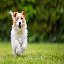

In [23]:
# Load image
img = image.load_img(r"..\assets\pictures\predict\dogs\predict-dog1.jpg", target_size=(64, 64))
img

In [24]:
# Convert the image to array
img = image.img_to_array(img) 
img

array([[[ 40.,  52.,   4.],
        [ 49.,  60.,   0.],
        [ 53.,  63.,   2.],
        ...,
        [ 62.,  65.,   8.],
        [ 43.,  56.,  10.],
        [ 47.,  60.,   7.]],

       [[ 35.,  43.,   4.],
        [ 42.,  50.,   1.],
        [ 43.,  53.,   1.],
        ...,
        [ 54.,  64.,   3.],
        [ 50.,  62.,  14.],
        [ 55.,  63.,  12.]],

       [[ 43.,  49.,   1.],
        [ 38.,  46.,   0.],
        [ 42.,  50.,   1.],
        ...,
        [ 39.,  52.,   6.],
        [ 59.,  70.,  14.],
        [ 70.,  79.,  12.]],

       ...,

       [[146., 169.,  53.],
        [161., 173.,  87.],
        [163., 176.,  70.],
        ...,
        [100., 118.,  36.],
        [122., 138.,  49.],
        [125., 138.,  56.]],

       [[146., 168.,  70.],
        [145., 169.,  59.],
        [144., 165.,  64.],
        ...,
        [143., 151.,  52.],
        [120., 144.,  50.],
        [112., 131.,  41.]],

       [[149., 168.,  63.],
        [141., 166.,  49.],
        [142., 1

In [25]:
# Change the dimensions of image
import numpy as np

In [26]:
img = np.expand_dims(img, axis=0)

In [27]:
cnn.predict(img) # New prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[0.00299236]], dtype=float32)

In [28]:
# To get the output in desired form
p = cnn.predict(img)
if p[0][0] < 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Dog


In [29]:
"""Predict the multiple values from the folder"""

'Predict the multiple values from the folder'

In [30]:
# Create an ImageDataGenerator for prediction
predict_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [31]:
# Generate batches of images from the specified directory for prediction
predict_generator = predict_datagen.flow_from_directory(
    r"..\assets\pictures\predict", target_size=(64, 64), batch_size=32, class_mode=None, shuffle=False
)

Found 4 images belonging to 2 classes.


In [32]:
# Make predictions
predictions = cnn.predict(predict_generator)

C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step


In [33]:
# Convert predictions to class labels
threshold = 0.5
predicted_classes = np.where(predictions > threshold, "Dog", "Cat")

In [34]:
# Get the filenames
filenames = predict_generator.filenames

In [35]:
# Combine filenames and predictions
results = list(zip(filenames, predicted_classes))

In [36]:
# Print the results
for filename, prediction in results:
    print(f"File: {filename}, Predicted Class: {prediction}")

File: cats\predict-cat1.jpg, Predicted Class: ['Cat']
File: dogs\predict-dog1.jpg, Predicted Class: ['Cat']
File: dogs\predict-dog2.jpg, Predicted Class: ['Cat']
File: dogs\predict-dog3.jpg, Predicted Class: ['Cat']
